## EEG data in the dying human brain : stages





DATASET : 

- Original paper :  Surge of neurophysiological coupling and connectivity of gamma oscillations in the dying human brain (Xu et al.,2023) https://www.pnas.org/doi/abs/10.1073/pnas.2216268120

- Data available here : https://zenodo.org/records/7803212#.ZC3Cb-zML0q

- Supporting information available here : https://universityofsussex-my.sharepoint.com/:b:/r/personal/rb666_sussex_ac_uk/Documents/Projects/LZ%20NDE/Supplementary%20pnas.2216268120.sapp.pdf?csf=1&web=1&e=TY5ZjD

---------------------------------------------------------------------

@Code : Romy Beauté\
@Contact : r.beaut@sussex.ac.uk\
@Date : 22/02/24\
@Last modified : 22/02/24

In [1]:
# %matplotlib widget
%matplotlib inline


import matplotlib
import matplotlib.pyplot as plt
import mne
import numpy as np
import os
import sys
from helpers.helper4pipeline import read_EEG,stage_annotations
from helpers.stages_infos import *
from helpers.preprocessing4pipeline import raw_preprocess, check_channels



In [2]:
# #####################  SELECT DATASET ####################################################################
DATASET_name = "Gang_2023"
patient = 1
stage = 1#"2-end" #can be 1 or "2-end"
############################################################################################################


DATASET_path = os.path.expanduser(f"~/projects/DATA/EEG/{DATASET_name}")
preprocessed_folder = os.path.join(DATASET_path, "preprocessed")
save_preproc = True

EEG_files = os.listdir(DATASET_path)
print(f"EEG files in {DATASET_name} : {[file for file in EEG_files if file.endswith('.edf')]}")

EEG_S1 = f"Pt{patient}_S1.edf" #correspond to stage S1 (comatose baseline)
EEG_S2_end = f"Pt{patient}_S2-end.edf" #correspond to stage S2 to the end of the recording (dying stages)

stages_dict = timing_stages() #load the timing of the stages from helpers stage infos 



EEG files in Gang_2023 : ['Pt2_S1.edf', 'Pt1_S2-end.edf', 'Pt4_S2-end.edf', 'Pt4_S1.edf', 'Pt3_S2-end.edf', 'Pt3_S1.edf', 'Pt1_S1.edf', 'Pt2_S2-end.edf']


EEG file : Pt1_S1.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 61439  =      0.000 ...   119.998 secs...
-----------------------------------------------------------------------------
Duration of Pt1_S1.edf recording: 120.0 seconds
No annotations in Pt1_S1.edf
-----------------------------------------------------------------------------
EEG file : Pt1_S2-end.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S2-end.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 275455  =      0.000 ...   537.998 secs...
-----------------------------------------------------------------------------
Duration of Pt1_S2-end.edf recording: 538.0 seconds
No annotations in Pt1_S2-end.edf
-----------------------------------------------------------------------------
No existing annotations

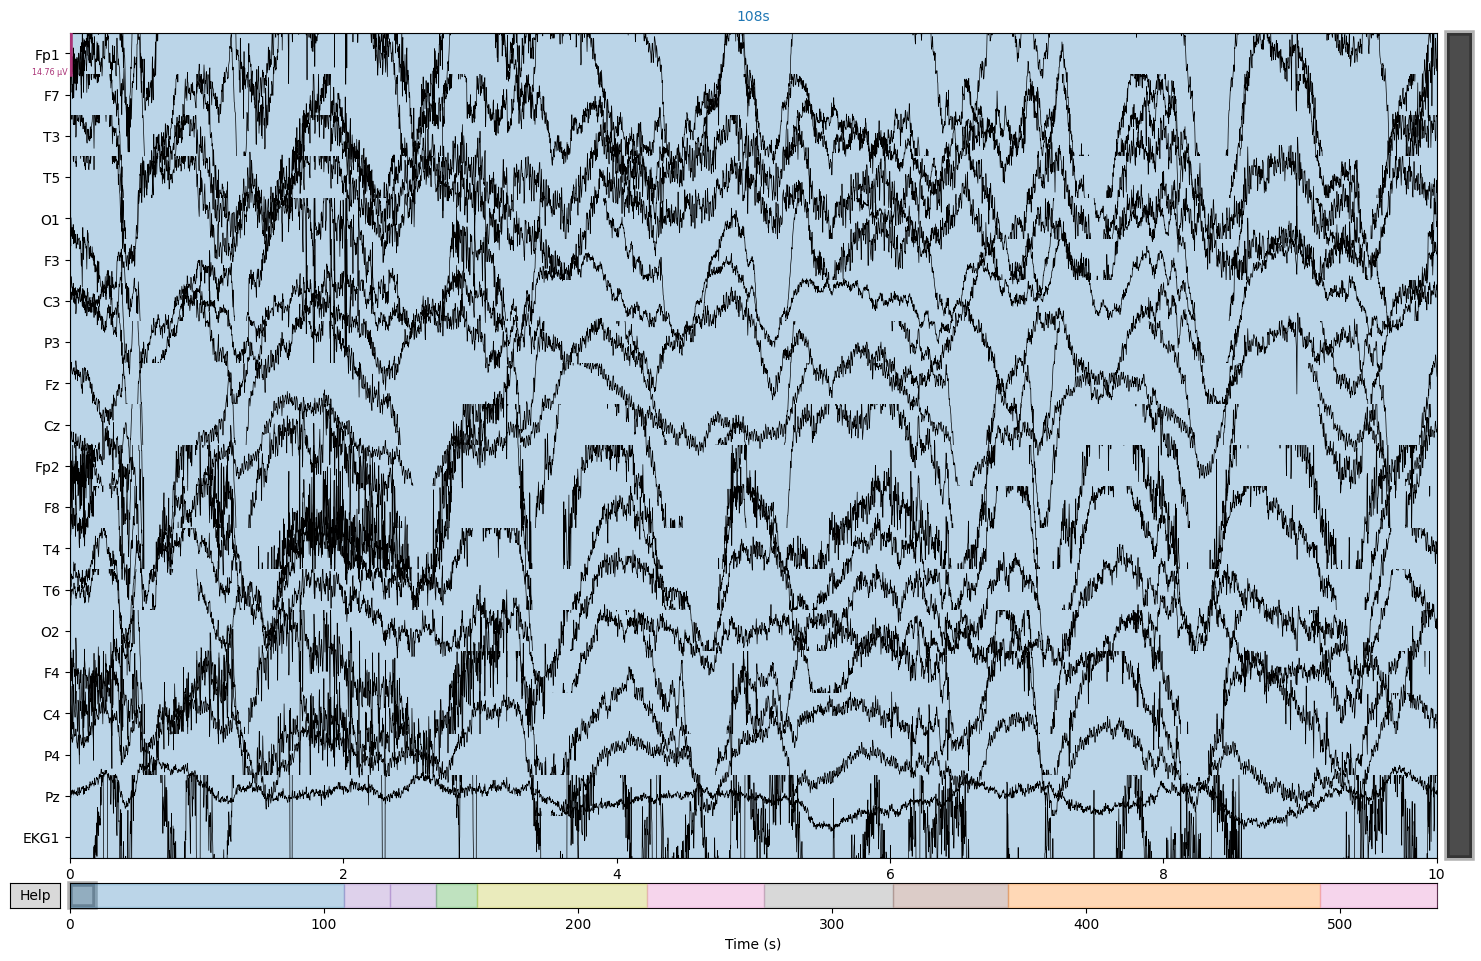

<Annotations | 10 segments: 108s (1), 123s (1), 16s (1), 18s (2), 45s (1), ...>

In [3]:
raw_eeg_baseline  = read_EEG(EEG_S1,DATASET_path,print_infos=False,plot_raw=False) #function from visualisation.py, read and visuale the EEG, does not do any preprocessing
raw_eeg_end = read_EEG(EEG_S2_end,DATASET_path,print_infos=False,plot_raw=False)

stage_annotations(raw_eeg_end,time_values,stages_dict,patient,stage_start=1,plot=True)

raw_eeg_end.annotations #check if annotations applied

### Defining the Near Death stages

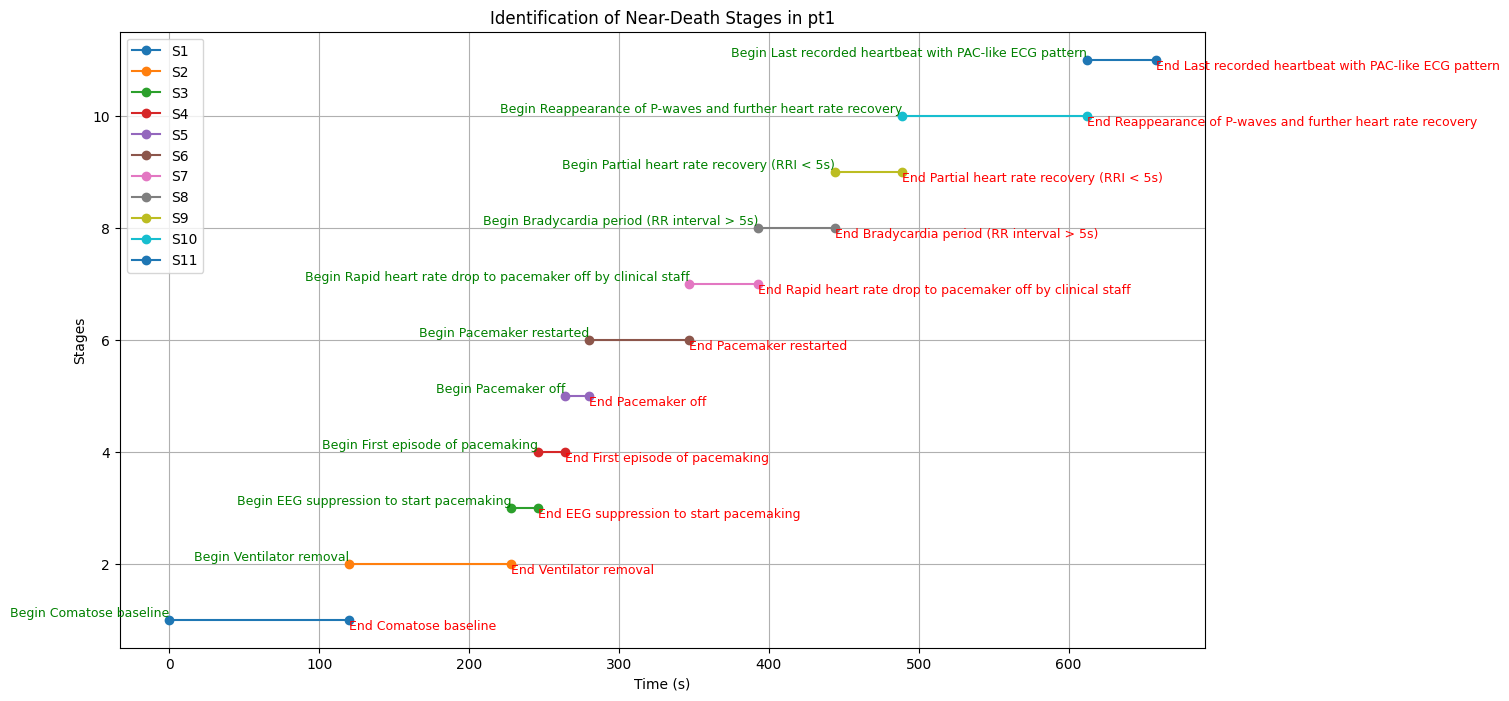

Existing annotations found:
<Annotations | 10 segments: 108s (1), 123s (1), 16s (1), 18s (2), 45s (1), ...>


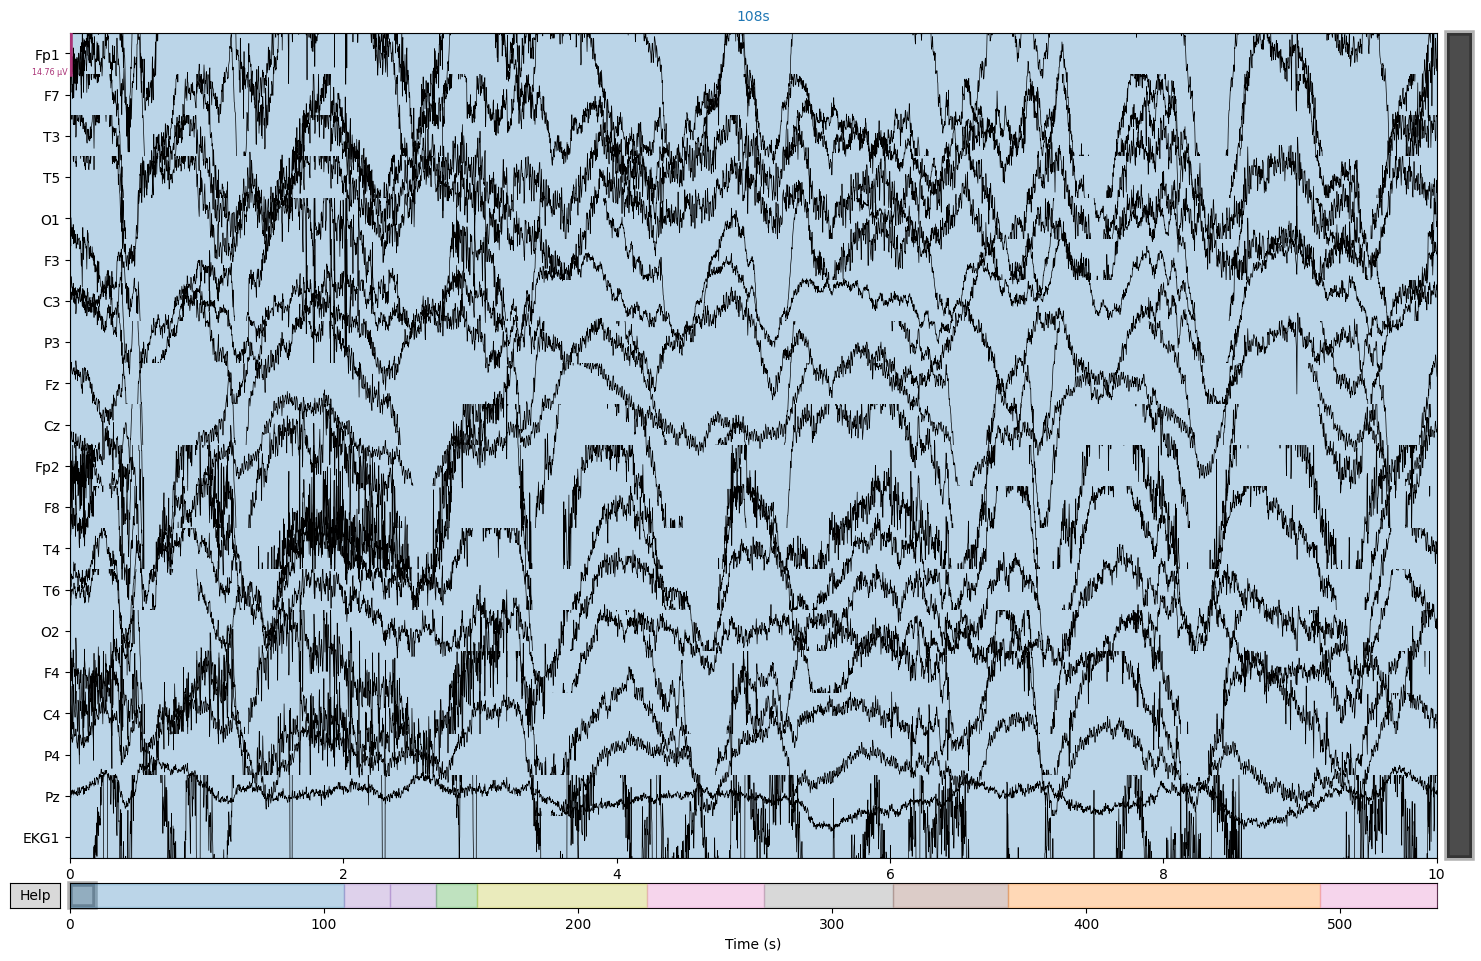

Used Annotations descriptions: ['108s', '123s', '16s', '18s', '45s', '46s', '51s', '67s']


In [4]:
for patient_id in time_values.keys():
    if patient_id == f"pt{patient}": #keep only pt 1 just for visualisation purposes
        plot_patient_stages(patient_id, time_values[patient_id], stage_descriptions[patient_id])
        stage_annotations(raw_eeg_end, time_values,stage_descriptions, patient,stage_start=1,plot=True)
        mne.events_from_annotations(raw_eeg_end)

### Preprocessing starts 

In [5]:
# ##################### PREPROC PARAMS ####################################################################
baseline_correction = False
epoch_duration = 2.0
detrend = True
normalise = True
save_preproc = True
apply_hilbert = False
apply_ica = False
notch_filter = [60, 120, 180]
downsampling = 250
############################################################################################################

#preprocessing for baseline (Stage 1)
raw_EEG_baseline,raw_ECG_baseline = check_channels(raw_eeg_baseline)
eeg_baseline,epochs_baseline = raw_preprocess(raw_eeg_baseline,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=False,normalise=True,apply_hilbert=False,apply_ica=False,plot_preproc=False)


#preprocessing for end (Stage 2-end)
raw_EEG_end,raw_ECG_end = check_channels(raw_eeg_end)
eeg_end,epochs_end = raw_preprocess(raw_eeg_end,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=False,normalise=True,apply_hilbert=False,apply_ica=False,plot_preproc=False)

All channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz', 'EKG1']
Using channel EKG1 to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 5120 samples (10.000 s)

Number of ECG events detected : 165 (average pulse 82 / min.)
Selected EEG channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Addi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Number of ECG events detected : 474 (average pulse 52 / min.)
Selected EEG channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Average reference projection applied.
<Annotations | 10 segments: 108s (1), 123s (1), 16s (1), 18s (2), 45s (1), ...>
Used Annotations descriptions: ['108s', '123s', '16s', '18s', '45s', '46s', '51s', '67s']
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- W

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


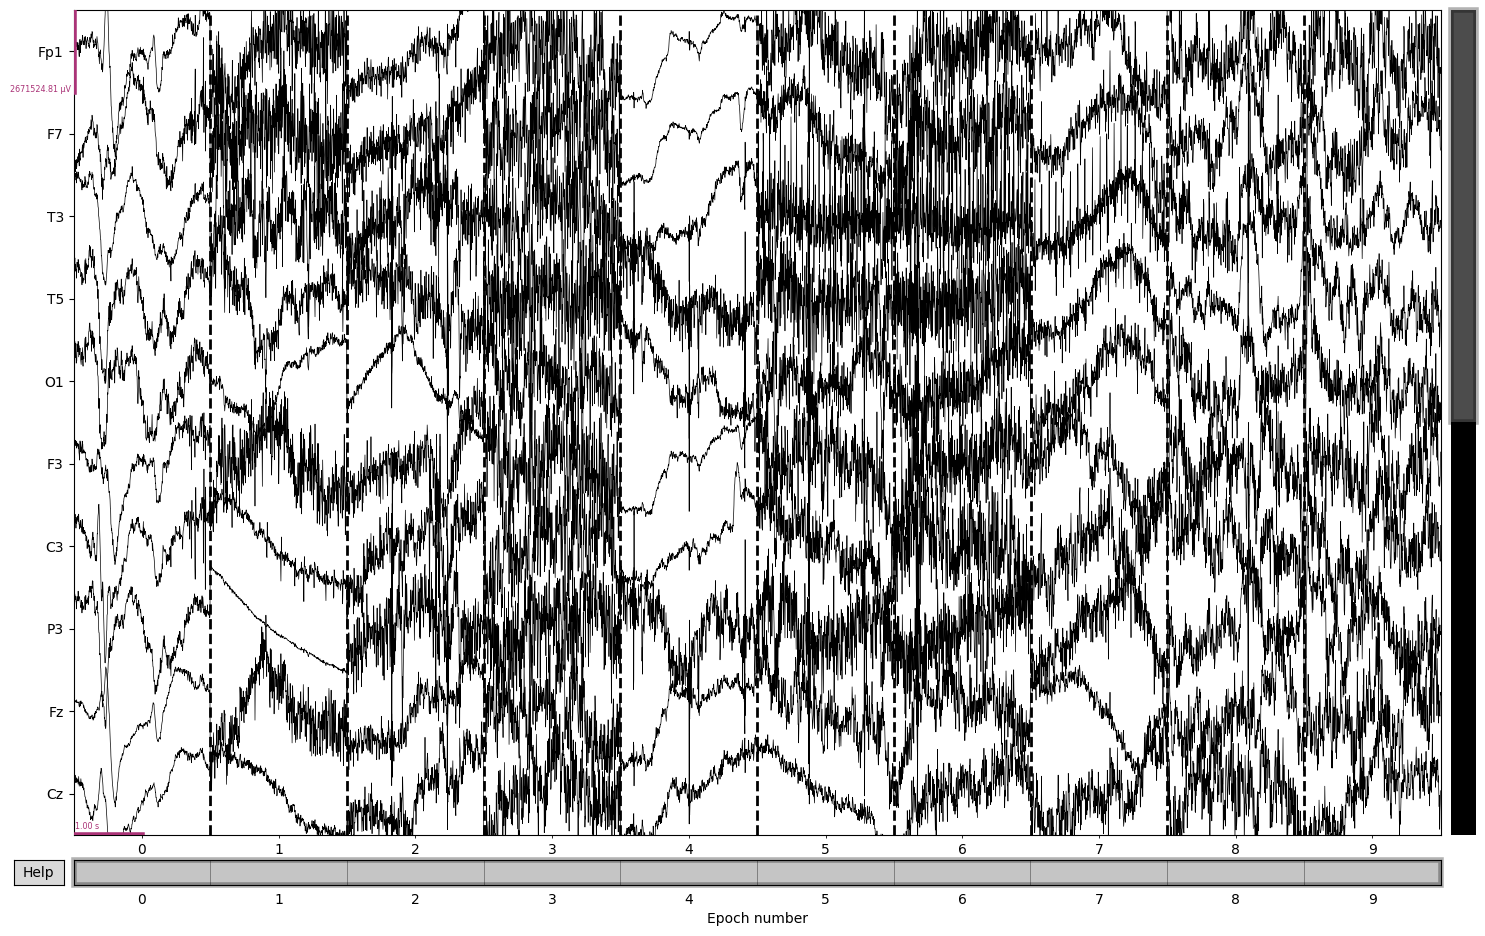

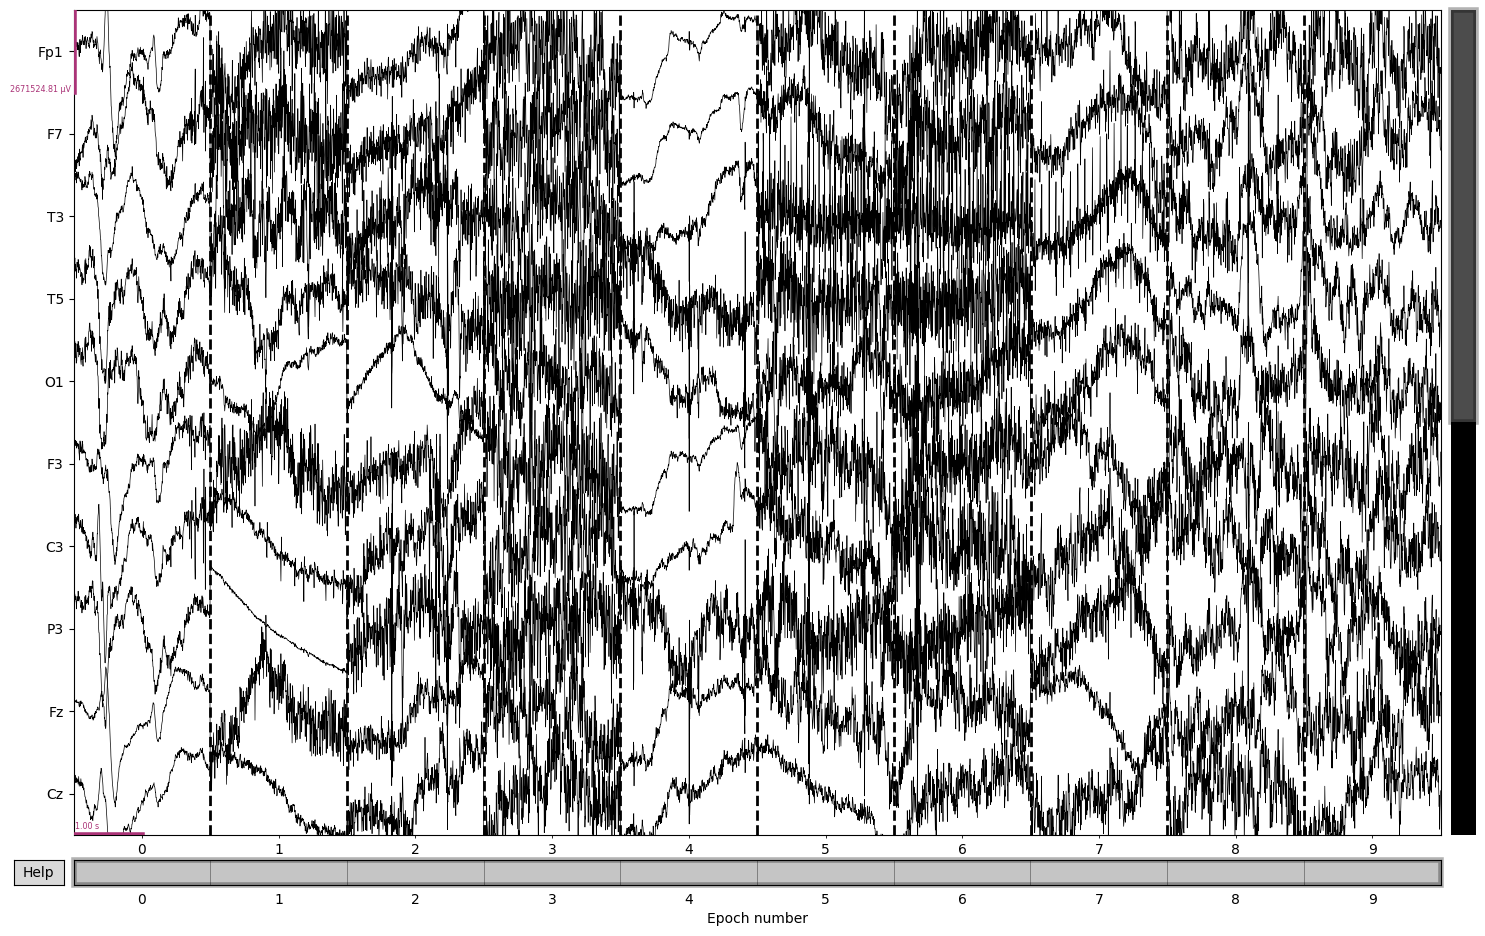

In [6]:

epochs_end.plot(n_epochs=10, n_channels=10, picks='eeg',scalings='auto') #plot the first 10 epochs of the EEG

In [83]:
# #save preprocessing file and parameters

# if save_preproc:

#     # Check if "preprocessed" folder exists
#     if not os.path.exists(preprocessed_folder):
#         os.makedirs(preprocessed_folder)

#     # Define the path for the preprocessed data
#     preprocessed_file_name = EEG_file.replace('.edf', '_preprocessed_eeg.fif')
#     preprocessed_file_path = os.path.join(preprocessed_folder, preprocessed_file_name)

#     # Define the path for the text file with preprocessing parameters
#     preprocessing_params_file_path = preprocessed_file_path.replace('.fif', '.txt')

#     # Save preprocessed data
#     if save_preproc:
#         if event_ids:
#             epochs_resampled.save(preprocessed_file_path, overwrite=True)
#         else:
#             raw_filtered.save(preprocessed_file_path, overwrite=True)

#         # Write preprocessing parameters to text file
#         with open(preprocessing_params_file_path, 'w') as f:
#             f.write(f"Preprocessing parameters for {EEG_file}:\n")
#             f.write(f"Notch filter applied at 60Hz\n")
#             if event_ids:
#                 f.write(f"Epoch duration: {epoch_duration} seconds\n")
#             else:
#                 f.write(f"No events found in the annotations. Working on the whole dataset ({raw_filtered.times[-1]}) seconds\n")
#             f.write("Baseline correction: {}\n".format('Yes' if baseline_correction else 'No'))
#             f.write("Resampled to 250Hz\n")



Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_preprocessed_eeg.fif
[done]
